# QCQP Example Pipeline

Interactive walkthrough of the QCQP example pipeline:

$$\min_{x,y}~(x-a)^2 + (y-b)^2 \quad \text{s.t.}~xy \geq 1$$

Each section below corresponds to one stage of the pipeline (`scripts/generate_qcqp_data.py`, `scripts/train_qcqp.py`, `scripts/evaluate_results.py`), but run inline so you can tweak parameters -- number of samples, sample-space bounds, network size/depth, number of epochs, etc. -- and immediately see the effect.

## Setup

In [ ]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path(".").resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from problems.qcqp_example.problem import solve_relaxation, solve_local, _build_sdp_problem
from problems.qcqp_example.generate_data import sample_parameters
from nn.models import DNN
from nn.training import cross_validate, save_model
from nn.metrics import error_summary

## Stage 1: Generate labeled data

Tweak `N_SAMPLES`, `BOUNDS`, and `SEED` below. `solve_relaxation` returns the SDP relaxation's optimal value (a valid lower bound, exact when `result["exact"]` is `True`).

In [2]:
# --- Parameters to play with ---
N_SAMPLES = 1000
BOUNDS = (-10, 10)
SEED = 0
# --------------------------------

sample_args = {"bounds": BOUNDS, "seed": SEED}
P = sample_parameters(N_SAMPLES, args=sample_args)

prob, M0, X = _build_sdp_problem()
relax_args = {"prob": prob, "M0": M0, "X": X}

costs, exact_flags = [], []
for p in P:
    value, result = solve_relaxation(p, args=relax_args)
    costs.append(value)
    exact_flags.append(result["exact"])

df_data = pd.DataFrame({"a": P[:, 0], "b": P[:, 1], "Cost": costs, "Exact": exact_flags})
print(f"Generated {len(df_data)} samples ({df_data['Exact'].sum()} exact)")
df_data.head()

Generated 1000 samples (1000 exact)


,a,b,Cost,Exact
0,2.739234,-4.604266,8.722110e+00,True
1,-9.180530,-9.669447,3.812236e-09,True
2,6.265405,8.255112,4.475956e-10,True
3,2.132716,4.589931,3.198914e-11,True
4,0.872500,8.701448,-1.485703e-10,True


### Visualize the labeled data

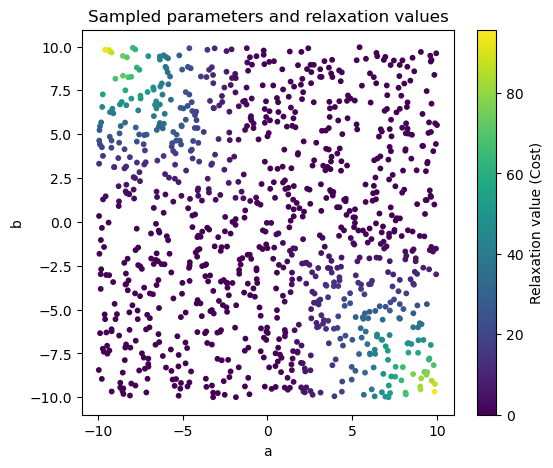

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df_data["a"], df_data["b"], c=df_data["Cost"], cmap="viridis", s=10)
plt.colorbar(sc, label="Relaxation value (Cost)")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("Sampled parameters and relaxation values")
plt.show()

### (Optional) save the dataset to disk

Saves to the same location used by `scripts/train_qcqp.py`, so the rest of the pipeline can pick it up.

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "qcqp_example"
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_path = DATA_DIR / f"training_QCQP_example_2d_{N_SAMPLES}samples.csv"
df_data.to_csv(data_path, index=False)
print(f"Saved to {data_path}")

Saved to /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/data/qcqp_example/training_QCQP_example_2d_1000samples.csv


## Stage 2: Train a DNN with k-fold cross-validation

Tweak `HIDDEN_DIMS` (network width/depth), `N_SPLITS`, `N_EPOCHS`, `LEARNING_RATE`, etc.

In [5]:
# --- Parameters to play with ---
HIDDEN_DIMS = (64, 64)
N_SPLITS = 2
N_EPOCHS = 500
LEARNING_RATE = 1e-3
BATCH_SIZE = 50
# --------------------------------

X_arr, y_arr = df_data[["a", "b"]].values, df_data["Cost"].values

fold_results = cross_validate(
    X_arr, y_arr,
    model_fn=lambda: DNN(input_dim=2, hidden_dims=HIDDEN_DIMS),
    n_splits=N_SPLITS,
    batch_size=BATCH_SIZE,
    random_state=SEED,
    train_kwargs=dict(
        n_epochs=N_EPOCHS,
        learning_rate=LEARNING_RATE,
        verbose=True,
    ),
)

Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 260.79it/s]


### Training curves

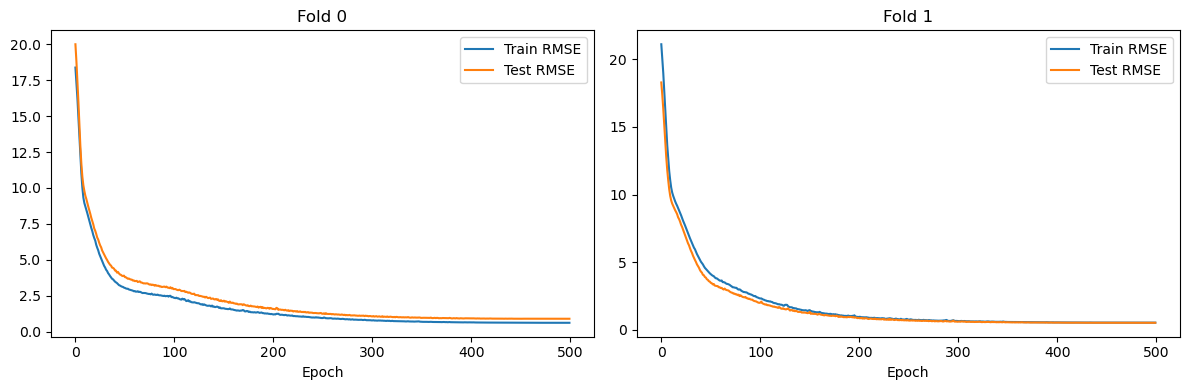

In [6]:
fig, axes = plt.subplots(1, len(fold_results), figsize=(6 * len(fold_results), 4), squeeze=False)
for fold in fold_results:
    ax = axes[0, fold["fold"]]
    ax.plot(np.sqrt(fold["train_history"]), label="Train RMSE")
    ax.plot(np.sqrt(fold["test_history"]), label="Test RMSE")
    ax.set_title(f"Fold {fold['fold']}")
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

### (Optional) save fold models + out-of-fold predictions

In [7]:
MODEL_DIR = PROJECT_ROOT / "models" / "qcqp_example"
RESULTS_DIR = PROJECT_ROOT / "results" / "qcqp_example"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pred_dfs = []
for fold in fold_results:
    save_path = MODEL_DIR / f"dnn_QCQP_example_2d_{N_SAMPLES}samples_fold{fold['fold']}.pth"
    save_model(fold["model"], save_path)
    pred_dfs.append(pd.DataFrame({"fold": fold["fold"], "Cost": fold["y_true"], "Pred": fold["y_pred"]}))

df_preds = pd.concat(pred_dfs, ignore_index=True)
preds_path = RESULTS_DIR / f"cv_predictions_QCQP_example_2d_{N_SAMPLES}samples.csv"
df_preds.to_csv(preds_path, index=False)
print(f"Saved predictions to {preds_path}")

Saved predictions to /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/results/qcqp_example/cv_predictions_QCQP_example_2d_1000samples.csv


## Stage 3: Evaluate prediction error

In [8]:
for fold in fold_results:
    stats = error_summary(fold["y_true"], fold["y_pred"])
    print(
        f"Fold {fold['fold']}: "
        f"mean abs error = {stats['mean_abs_error']:.4f} "
        f"(95% CI: [{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]), "
        f"max abs error = {stats['max_abs_error']:.4f} "
        f"(n={stats['n']})"
    )

y_true_all = np.concatenate([fold["y_true"] for fold in fold_results])
y_pred_all = np.concatenate([fold["y_pred"] for fold in fold_results])
overall = error_summary(y_true_all, y_pred_all)
print(
    f"Overall: "
    f"mean abs error = {overall['mean_abs_error']:.4f} "
    f"(95% CI: [{overall['ci_lower']:.4f}, {overall['ci_upper']:.4f}]), "
    f"max abs error = {overall['max_abs_error']:.4f} "
    f"(n={overall['n']})"
)

Fold 0: mean abs error = 0.4536 (95% CI: [0.3855, 0.5216]), max abs error = 7.8430 (n=500)
Fold 1: mean abs error = 0.3312 (95% CI: [0.2953, 0.3672]), max abs error = 2.9378 (n=500)
Overall: mean abs error = 0.3924 (95% CI: [0.3537, 0.4311]), max abs error = 7.8430 (n=1000)


### Residual histogram

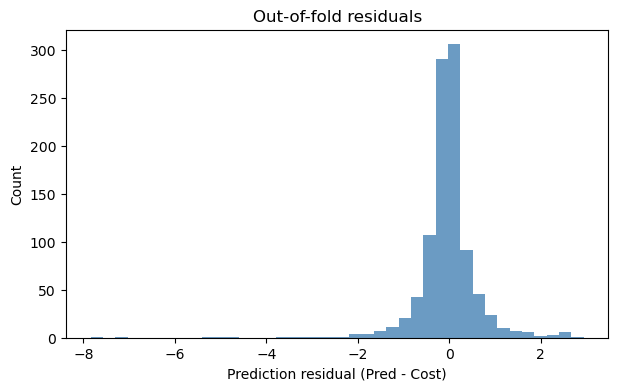

In [9]:
residuals = y_pred_all - y_true_all
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color="steelblue", alpha=0.8)
plt.xlabel("Prediction residual (Pred - Cost)")
plt.ylabel("Count")
plt.title("Out-of-fold residuals")
plt.show()

## Bonus: visualize the learned value function vs. true relaxation value

Trains a single model on all data (not cross-validated) for a quick visual sanity check, and compares against `solve_local` at a few points.

In [10]:
model = DNN(input_dim=2, hidden_dims=HIDDEN_DIMS)
from nn.training import to_loader, train_model

full_loader = to_loader(X_arr, y_arr, batch_size=BATCH_SIZE, shuffle=True)
model, _, _ = train_model(
    model, full_loader, full_loader,
    n_epochs=N_EPOCHS, learning_rate=LEARNING_RATE,
    verbose=True,
)

Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 130.28it/s]


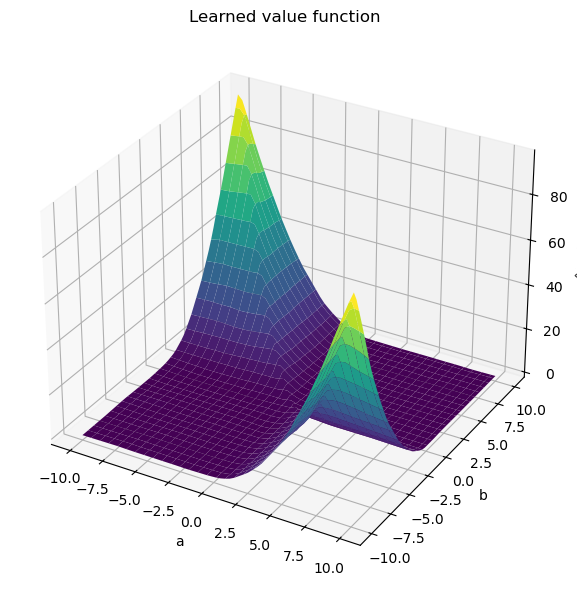

In [11]:
import torch

a_vals = np.linspace(BOUNDS[0], BOUNDS[1], 60)
b_vals = np.linspace(BOUNDS[0], BOUNDS[1], 60)
A, B = np.meshgrid(a_vals, b_vals)
coords = np.stack([A.ravel(), B.ravel()], axis=1)

with torch.no_grad():
    V_hat = model(torch.tensor(coords, dtype=torch.float32)).numpy().reshape(A.shape)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(A, B, V_hat, cmap="viridis")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel(r"$\hat{v}(a,b)$")
ax.set_title("Learned value function")
plt.tight_layout()
plt.show()

In [12]:
# Compare prediction, relaxation value, and local-search value at a few points
test_points = [(-2, 1), (0, 0), (3, 3), (-4, -4)]

for a, b in test_points:
    relax_val, _ = solve_relaxation((a, b), args=relax_args)
    local_val, _ = solve_local((a, b))
    with torch.no_grad():
        pred_val = model(torch.tensor([[a, b]], dtype=torch.float32)).item()
    print(f"p=({a:.1f}, {b:.1f}): relaxation={relax_val:.4f}  local={local_val:.4f}  DNN pred={pred_val:.4f}")

p=(-2.0, 1.0): relaxation=2.1480  local=7.1708  DNN pred=2.0292
p=(0.0, 0.0): relaxation=2.0000  local=2.0000  DNN pred=1.2966
p=(3.0, 3.0): relaxation=0.0000  local=0.0000  DNN pred=0.0741
p=(-4.0, -4.0): relaxation=0.0000  local=50.0000  DNN pred=-0.0097


/Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/problems/qcqp_example/problem.py:96: RuntimeWarning: divide by zero encountered in divide
  v = v / v[0]  # normalize so v[0] == X[0,0]**0.5 == 1
/Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/problems/qcqp_example/problem.py:96: RuntimeWarning: invalid value encountered in divide
  v = v / v[0]  # normalize so v[0] == X[0,0]**0.5 == 1


## Stage 4: Certify optimality of the local solver

For each test point, we compute the SDP relaxation value (ground truth lower bound),
the local solver's (IPOPT) value, and the DNN's predicted value. A local solution is
*actually* optimal if `|LocalCost - Cost| <= TOL` (relaxation is tight at that value),
and the DNN *certifies* optimality if `|LocalCost - Pred| <= TOL`. Tweak `N_TEST_SAMPLES`,
`TEST_SEED`, and `TOL` below.

**Note:** `solve_local` requires IPOPT via Pyomo. On macOS in the `nn4opt` conda env,
launch this notebook's kernel with `DYLD_FALLBACK_LIBRARY_PATH=/opt/anaconda3/envs/nn4opt/lib`
set (see README) or this cell will fail with a `dyld`/`liblapack` error.

In [15]:
# --- Parameters to play with ---
N_TEST_SAMPLES = 200
TEST_SEED = 1
TOL = 1
# --------------------------------

from nn.metrics import optimality_confusion_matrix

P_test = sample_parameters(N_TEST_SAMPLES, args={"bounds": BOUNDS, "seed": TEST_SEED})

test_costs, test_local_costs, test_preds = [], [], []
for p in P_test:
    value, _ = solve_relaxation(p, args=relax_args)
    test_costs.append(value)

    local_value, _ = solve_local(p)
    test_local_costs.append(local_value)

    with torch.no_grad():
        pred_value = model(torch.tensor([p], dtype=torch.float32)).item()
    test_preds.append(pred_value)

df_test = pd.DataFrame({
    "a": P_test[:, 0], "b": P_test[:, 1],
    "Cost": test_costs, "LocalCost": test_local_costs, "Pred": test_preds,
})

cm = optimality_confusion_matrix(df_test["Cost"], df_test["LocalCost"], df_test["Pred"], tol=TOL)

print(f"Optimality certification (tol={TOL}), n={cm['n']}")
print(f"{'':>20} {'Predicted Optimal':>18} {'Predicted Suboptimal':>22}")
print(f"{'Actually Optimal':>20} {cm['tp']:>18} {cm['fn']:>22}")
print(f"{'Actually Suboptimal':>20} {cm['fp']:>18} {cm['tn']:>22}")
print()
print(f"False positive rate: {cm['fpr']:.4f}")
print(f"False negative rate: {cm['fnr']:.4f}")

Optimality certification (tol=1), n=200
                      Predicted Optimal   Predicted Suboptimal
    Actually Optimal                106                      0
 Actually Suboptimal                  0                     94

False positive rate: 0.0000
False negative rate: 0.0000
